## 0. Imports and shared configuration

In [15]:
import warnings
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

warnings.filterwarnings('ignore')

# Project imports
from simulation import Simulation
from welfare_layer import WelfareAwareOrchestrator, TravelCostEstimator
from oracle_rs import OracleRecommender, OracleOrchestrator, register_agent_from_abm
from experiment_harness import (
    gini_coefficient, over_recommendation_cost, calibrate_rm_epsilon,
)

print('Imports OK.')

Imports OK.


In [44]:
# ── Simulation parameters (shared across every section) ─────────────────
NUM_AGENTS = 250        # agents per simulation
CITY_SIZE  = 18         # grid dimension
NUM_DAYS   = 60         # simulation horizon
TIME_STEP  = 5          # minutes per tick
SEEDS      = [11, 13, 17, 19, 23]   # matched seeds for variance estimation
CONTEXT    = {'weather': 'fair', 'travel_norm': 'neutral'}

# ── Welfare-constraint thresholds used by the ORC treatments ───────────
PUP_ALPHA  = 0.6        # P(U >= 0) must exceed this
RM_EPSILON = 0.94     # E[regret] must be below this

# ── Treatments for Table 1, the paradigm heatmap, and the ORC table ────
TREATMENTS = [
    {'name': 'no_rs',    'use_rs': False, 'factory': None},
    {'name': 'standard', 'use_rs': True,  'factory': None},
    {'name': 'pup_03',   'use_rs': True,  'factory': 'pup', 'pup_alpha': 0.3},
    {'name': 'pup_06',   'use_rs': True,  'factory': 'pup', 'pup_alpha': 0.6},
    {'name': 'rm',       'use_rs': True,  'factory': 'rm',  'rm_epsilon': RM_EPSILON},
    {'name': 'oracle',   'use_rs': True,  'factory': 'oracle'},
]

# Display labels for tables/plots
DISPLAY_NAMES = {
    'no_rs':    'No RS',
    'standard': 'Standard RS',
    'pup_03':   'PUP-0.3',
    'pup_06':   'PUP-0.6',
    'rm':       f'RM ($\\epsilon$={RM_EPSILON})',
    'oracle':   'Oracle',
}

# ── Sweep ranges used only for the frontier figures (Figs 2 & 3) ───────
PUP_ALPHAS     = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
RM_PERCENTILES = [50, 65, 70, 75, 80, 85, 90, 95, 99]

print(f'{NUM_AGENTS} agents · {CITY_SIZE}x{CITY_SIZE} city · {NUM_DAYS} days · {len(SEEDS)} seeds')
print(f'Treatments: {[t["name"] for t in TREATMENTS]}')

250 agents · 18x18 city · 60 days · 5 seeds
Treatments: ['no_rs', 'standard', 'pup_03', 'pup_06', 'rm', 'oracle']


In [45]:
# ── Factory helpers ─────────────────────────────────────────────────────
def _make_pup_factory(alpha):
    def factory(sim, base_stack):
        tce = TravelCostEstimator(default_vot=15.0, learning_rate=0.15)
        return WelfareAwareOrchestrator(
            base_orchestrator=base_stack, travel_cost_estimator=tce,
            mode='pup', pup_alpha=alpha, coord_scale_km=sim.city.block_km,
        )
    return factory


def _make_rm_factory(epsilon):
    def factory(sim, base_stack):
        tce = TravelCostEstimator(default_vot=15.0, learning_rate=0.15)
        return WelfareAwareOrchestrator(
            base_orchestrator=base_stack, travel_cost_estimator=tce,
            mode='rm', rm_epsilon=epsilon, coord_scale_km=sim.city.block_km,
        )
    return factory


def _make_standard_factory():
    def factory(sim, base_stack):
        tce = TravelCostEstimator(default_vot=15.0, learning_rate=0.15)
        return WelfareAwareOrchestrator(
            base_orchestrator=base_stack, travel_cost_estimator=tce,
            mode='standard', coord_scale_km=sim.city.block_km,
        )
    return factory


def _make_oracle_factory():
    def factory(sim, base_stack):
        oracle = OracleRecommender(sim.place_catalog, coord_scale_km=sim.city.block_km)
        for agent in sim.agents:
            register_agent_from_abm(oracle, agent)
        return OracleOrchestrator(oracle)
    return factory


def _treatment_to_factory(treatment):
    """Turn a treatment dict into (use_rs, recommender_factory)."""
    if not treatment['use_rs']:
        return False, None
    ft = treatment.get('factory')
    if ft is None:
        return True, _make_standard_factory()
    if ft == 'pup':
        return True, _make_pup_factory(treatment['pup_alpha'])
    if ft == 'rm':
        return True, _make_rm_factory(treatment['rm_epsilon'])
    if ft == 'oracle':
        return True, _make_oracle_factory()
    raise ValueError(f'Unknown factory: {ft}')


def run_single(seed, use_recommenders=True, recommender_factory=None):
    """Run one simulation and return metrics needed by every section."""
    sim = Simulation(
        num_agents=NUM_AGENTS, city_size=CITY_SIZE, seed=seed,
        time_step=TIME_STEP, context=CONTEXT,
        use_recommenders=use_recommenders,
        recommender_factory=recommender_factory,
    )
    sim.run_days(num_days=NUM_DAYS)
    summary = sim.summarize()

    trip_utilities = []
    agent_utilities = {}   # agent_id -> total leisure utility
    agent_data = []        # one row per agent (for heterogeneity)
    for agent in sim.agents:
        leisure_trips = [t for t in agent.trips if t.purpose == 'leisure']
        utilities = [t.utility for t in leisure_trips]
        trip_utilities.extend(utilities)
        agent_utilities[agent.id] = float(sum(utilities))
        agent_data.append({
            'agent_id': agent.id,
            'paradigm': agent.decision_paradigms.get('mode_choice', 'utility'),
            'mean_utility': float(np.mean(utilities)) if utilities else 0.0,
            'total_utility': float(sum(utilities)),
            'num_leisure_trips': len(leisure_trips),
        })

    abstention_rate = 1.0 - summary.get('recommendation_acceptance_rate', 0.0)
    neg_rate = (sum(1 for u in trip_utilities if u < 0) / max(1, len(trip_utilities)))

    return {
        'trip_utilities':  trip_utilities,
        'agent_utilities': agent_utilities,
        'agent_data':      agent_data,
        'mean_utility':    float(np.mean(trip_utilities)) if trip_utilities else 0.0,
        'neg_utility_rate': neg_rate,
        'gini':             gini_coefficient(trip_utilities),
        'abstention_rate':  abstention_rate,
        'n_trips':          len(trip_utilities),
    }


print('Helpers defined.')

Helpers defined.


In [46]:
# ── Run the six Table-1 / heatmap / ORC treatments once and cache them ──
results = {}   # (treatment_name, seed) -> run_single(...) dict

for treatment in TREATMENTS:
    tname = treatment['name']
    use_rs, factory = _treatment_to_factory(treatment)
    print(f'\nTreatment: {tname}')
    for seed in SEEDS:
        print(f'  seed={seed}', end=' ')
        res = run_single(seed, use_recommenders=use_rs, recommender_factory=factory)
        results[(tname, seed)] = res
        print(f'done (mean U={res["mean_utility"]:.4f}, n={res["n_trips"]})')

print(f'\nCached {len(results)} matched (treatment, seed) runs.')


Treatment: no_rs
  seed=11 done (mean U=0.0591, n=132)
  seed=13 done (mean U=0.0288, n=165)
  seed=17 done (mean U=0.0679, n=161)
  seed=19 done (mean U=0.0687, n=156)
  seed=23 done (mean U=0.0371, n=157)

Treatment: standard
  seed=11 done (mean U=0.1401, n=166)
  seed=13 done (mean U=0.0478, n=151)
  seed=17 done (mean U=0.1659, n=158)
  seed=19 done (mean U=0.0342, n=149)
  seed=23 done (mean U=0.0574, n=155)

Treatment: pup_03
  seed=11 done (mean U=0.1588, n=149)
  seed=13 done (mean U=0.1840, n=143)
  seed=17 done (mean U=0.2387, n=149)
  seed=19 done (mean U=0.2749, n=152)
  seed=23 done (mean U=0.2122, n=144)

Treatment: pup_06
  seed=11 done (mean U=0.1964, n=147)
  seed=13 done (mean U=0.2536, n=153)
  seed=17 done (mean U=0.2901, n=157)
  seed=19 done (mean U=0.2078, n=150)
  seed=23 done (mean U=0.2091, n=149)

Treatment: rm
  seed=11 done (mean U=0.1937, n=152)
  seed=13 done (mean U=0.2481, n=147)
  seed=17 done (mean U=0.2745, n=161)
  seed=19 done (mean U=0.2839, n=1

## 1. Sensitivity analysis

Finds the optimal $\alpha$ (for PUP, **Figure 2**) and $\epsilon$ (for RM, **Figure 3**) and reports the aggregate welfare comparison summary (**Table 1**).

In [ ]:
# ── PUP α sweep (Figure 2) ──────────────────────────────────────────────
# We reuse the runs already cached in `results` for α = 0.3 and α = 0.6.
pup_cache_map = {0.3: 'pup_03', 0.6: 'pup_06'}
pup_results = {}   # alpha -> list of per-seed run dicts

for alpha in PUP_ALPHAS:
    if alpha in pup_cache_map and (pup_cache_map[alpha], SEEDS[0]) in results:
        pup_results[alpha] = [results[(pup_cache_map[alpha], s)] for s in SEEDS]
        print(f'PUP α = {alpha:.1f}  (reused from cache)')
        continue
    print(f'PUP α = {alpha:.1f}')
    runs = []
    for seed in SEEDS:
        print(f'  seed={seed}', end=' ')
        runs.append(run_single(seed, recommender_factory=_make_pup_factory(alpha)))
        print(f'done (mean U={runs[-1]["mean_utility"]:.4f})')
    pup_results[alpha] = runs

PUP α = 0.0
  seed=11 done (mean U=0.1401)
  seed=13 done (mean U=0.0478)
  seed=17 done (mean U=0.1659)
  seed=19 done (mean U=0.0342)
  seed=23 done (mean U=0.0574)
PUP α = 0.1
  seed=11 done (mean U=0.1635)
  seed=13 done (mean U=0.1802)
  seed=17 done (mean U=0.2404)
  seed=19 done (mean U=0.2385)
  seed=23 done (mean U=0.2365)
PUP α = 0.2
  seed=11 done (mean U=0.1942)
  seed=13 done (mean U=0.2997)
  seed=17 done (mean U=0.2829)
  seed=19 done (mean U=0.1957)
  seed=23 done (mean U=0.1077)
PUP α = 0.3
  seed=11 done (mean U=0.1588)
  seed=13 done (mean U=0.1840)
  seed=17 done (mean U=0.2387)
  seed=19 done (mean U=0.2749)
  seed=23 done (mean U=0.2122)
PUP α = 0.4
  seed=11 done (mean U=0.1996)
  seed=13 done (mean U=0.1915)
  seed=17 done (mean U=0.2065)
  seed=19 done (mean U=0.2068)
  seed=23 done (mean U=0.1439)
PUP α = 0.5
  seed=11 done (mean U=0.1764)
  seed=13 done (mean U=0.1943)
  seed=17 done (mean U=0.2591)
  seed=19 done (mean U=0.2065)
  seed=23 done (mean U=0.1803

In [34]:
# Save PUP-results 60 days
pup_results_60d = {alpha: pup_results[alpha] for alpha in PUP_ALPHAS}
pup_results_df = pd.DataFrame([
    {
        'alpha': alpha,
        'mean_utility': np.mean([run['mean_utility'] for run in runs]),
        'neg_utility_rate': np.mean([run['neg_utility_rate'] for run in runs]),
        'gini': np.mean([run['gini'] for run in runs]),
        'abstention_rate': np.mean([run['abstention_rate'] for run in runs]),
    }
    for alpha, runs in pup_results_60d.items()
]) 

pup_results_df.to_csv('outputs/pup_results_60d.csv', index=False)

In [42]:
# ── RM ε calibration + sweep (Figure 3) ─────────────────────────────────
# Calibrate ε at each percentile using the Standard-RS trip-utility
# distribution (proxy regret = max(0, mean - trip_utility)).
std_utils = np.array(
    [u for s in SEEDS for u in results[('standard', s)]['trip_utilities']]
)
regret_proxy = np.maximum(0.0, np.mean(std_utils) - std_utils)

rm_epsilons = {p: calibrate_rm_epsilon(regret_proxy, percentile=p) for p in RM_PERCENTILES}
print('Calibrated RM ε values:')
for p, e in rm_epsilons.items():
    print(f'  p{p} → ε = {e:.4f}')

rm_results = {}   # percentile -> {'epsilon': ε, 'runs': [per-seed run dicts]}
for pct, eps in rm_epsilons.items():
    print(f'\nRM ε = {eps:.4f} (p{pct})')
    runs = []
    for seed in SEEDS:
        print(f'  seed={seed}', end=' ')
        runs.append(run_single(seed, recommender_factory=_make_rm_factory(eps)))
        print(f'done (mean U={runs[-1]["mean_utility"]:.4f})')
    rm_results[pct] = {'epsilon': eps, 'runs': runs}

Calibrated RM ε values:
  p50 → ε = 0.0000
  p65 → ε = 0.1050
  p70 → ε = 0.1789
  p75 → ε = 0.2723
  p80 → ε = 0.3614
  p85 → ε = 0.5178
  p90 → ε = 0.6864
  p95 → ε = 0.9373
  p99 → ε = 1.5641

RM ε = 0.0000 (p50)
  seed=11 done (mean U=0.0591)
  seed=13 done (mean U=0.0288)
  seed=17 done (mean U=0.0679)
  seed=19 done (mean U=0.0687)
  seed=23 done (mean U=0.0371)

RM ε = 0.1050 (p65)
  seed=11 done (mean U=0.2553)
  seed=13 done (mean U=0.1546)
  seed=17 done (mean U=0.1679)
  seed=19 done (mean U=0.2325)
  seed=23 done (mean U=0.1432)

RM ε = 0.1789 (p70)
  seed=11 done (mean U=0.1563)
  seed=13 done (mean U=0.2369)
  seed=17 done (mean U=0.2016)
  seed=19 done (mean U=0.2414)
  seed=23 done (mean U=0.2184)

RM ε = 0.2723 (p75)
  seed=11 done (mean U=0.2015)
  seed=13 done (mean U=0.2098)
  seed=17 done (mean U=0.2287)
  seed=19 done (mean U=0.3040)
  seed=23 done (mean U=0.2358)

RM ε = 0.3614 (p80)
  seed=11 done (mean U=0.1703)
  seed=13 done (mean U=0.1929)
  seed=17 done (me

In [50]:
# Save RM-results 60 days
rm_results_60d = {pct: rm_results[pct] for pct in RM_PERCENTILES}
rm_results_df = pd.DataFrame([
    {
        'percentile': pct,
        'epsilon': rm_results[pct]['epsilon'],
        'mean_utility': np.mean([run['mean_utility'] for run in rm_results[pct]['runs']]),
        'neg_utility_rate': np.mean([run['neg_utility_rate'] for run in rm_results[pct]['runs']]),
        'gini': np.mean([run['gini'] for run in rm_results[pct]['runs']]),
        'abstention_rate': np.mean([run['abstention_rate'] for run in rm_results[pct]['runs']]),
    }
    for pct in RM_PERCENTILES
])
rm_results_df.to_csv('outputs/rm_results_60d.csv', index=False)

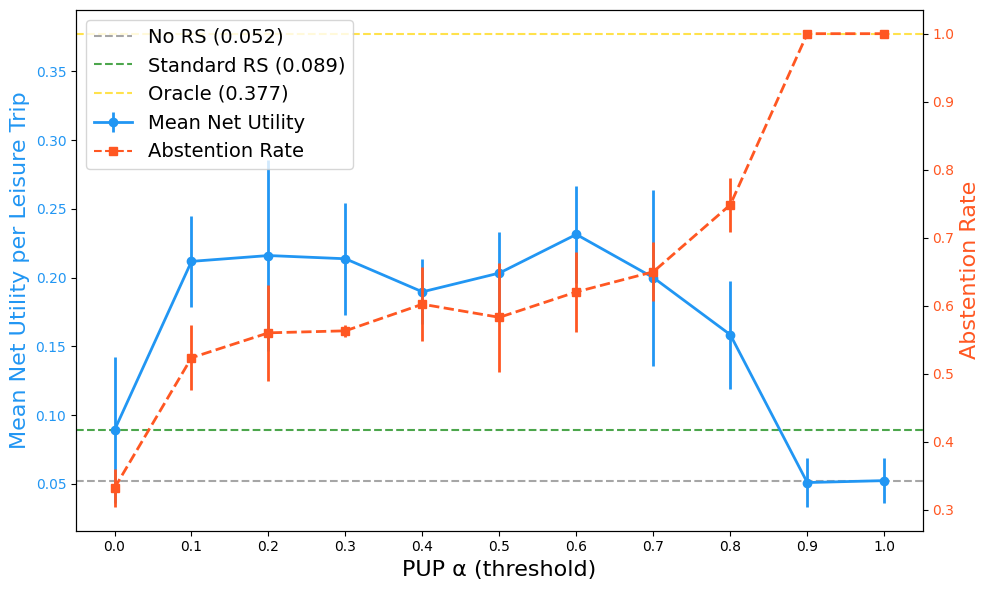

Best PUP α (max mean U) = 0.6 at U = 0.2314


In [27]:
# ── Figure 2: PUP threshold frontier ────────────────────────────────────
no_rs_mu  = np.mean([results[('no_rs',    s)]['mean_utility'] for s in SEEDS])
std_mu    = np.mean([results[('standard', s)]['mean_utility'] for s in SEEDS])
oracle_mu = np.mean([results[('oracle',   s)]['mean_utility'] for s in SEEDS])

color_u, color_a = '#2196F3', '#FF5722'
fig, ax1 = plt.subplots(figsize=(10, 6))

pup_mu   = [np.mean([r['mean_utility']    for r in pup_results[a]]) for a in PUP_ALPHAS]
pup_mu_s = [np.std ([r['mean_utility']    for r in pup_results[a]]) for a in PUP_ALPHAS]
pup_ab   = [np.mean([r['abstention_rate'] for r in pup_results[a]]) for a in PUP_ALPHAS]
pup_ab_s = [np.std ([r['abstention_rate'] for r in pup_results[a]]) for a in PUP_ALPHAS]

ax1.errorbar(PUP_ALPHAS, pup_mu, yerr=pup_mu_s, color=color_u, marker='o', linewidth=2, label='Mean Net Utility')
ax1.axhline(no_rs_mu,  color='gray',  linestyle='--', alpha=0.7, label=f'No RS ({no_rs_mu:.3f})')
ax1.axhline(std_mu,    color='green', linestyle='--', alpha=0.7, label=f'Standard RS ({std_mu:.3f})')
ax1.axhline(oracle_mu, color='gold',  linestyle='--', alpha=0.7, label=f'Oracle ({oracle_mu:.3f})')
ax1.set_xlabel('PUP α (threshold)', fontsize=16)
ax1.set_ylabel('Mean Net Utility per Leisure Trip', color=color_u, fontsize=16)
ax1.tick_params(axis='y', labelcolor=color_u)
ax1.set_xticks(PUP_ALPHAS)

ax2 = ax1.twinx()
ax2.errorbar(PUP_ALPHAS, pup_ab, yerr=pup_ab_s, color=color_a, marker='s', linewidth=2, linestyle='--')
ax2.set_ylabel('Abstention Rate', color=color_a, fontsize=16)
ax2.tick_params(axis='y', labelcolor=color_a)

lines1, _ = ax1.get_legend_handles_labels()
abst_line = Line2D([0], [0], color=color_a, marker='s', linestyle='--', label='Abstention Rate')
ax1.legend(handles=lines1 + [abst_line], fontsize=14, loc='upper left')
plt.tight_layout()
plt.show()

best_alpha = PUP_ALPHAS[int(np.argmax(pup_mu))]
print(f'Best PUP α (max mean U) = {best_alpha:.1f} at U = {max(pup_mu):.4f}')

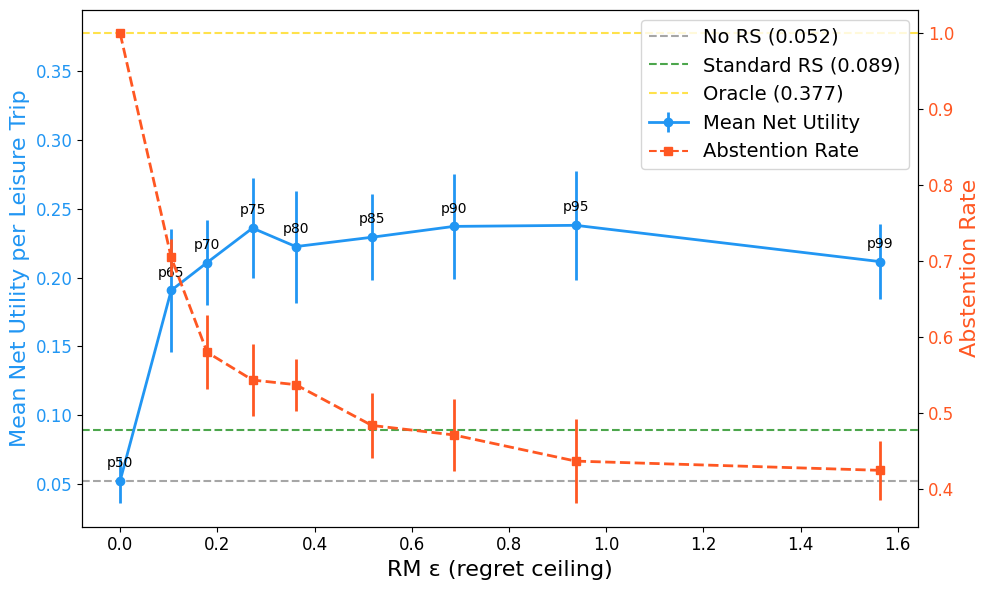

Best RM percentile (max mean U) = p95 (ε = 0.9373) at U = 0.2380


In [43]:
# ── Figure 3: RM threshold frontier ─────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(10, 6))

eps_vals = [rm_results[p]['epsilon'] for p in RM_PERCENTILES]
rm_mu    = [np.mean([r['mean_utility']    for r in rm_results[p]['runs']]) for p in RM_PERCENTILES]
rm_mu_s  = [np.std ([r['mean_utility']    for r in rm_results[p]['runs']]) for p in RM_PERCENTILES]
rm_ab    = [np.mean([r['abstention_rate'] for r in rm_results[p]['runs']]) for p in RM_PERCENTILES]
rm_ab_s  = [np.std ([r['abstention_rate'] for r in rm_results[p]['runs']]) for p in RM_PERCENTILES]

ax1.errorbar(eps_vals, rm_mu, yerr=rm_mu_s, color=color_u, marker='o', linewidth=2, label='Mean Net Utility')
ax1.axhline(no_rs_mu,  color='gray',  linestyle='--', alpha=0.7, label=f'No RS ({no_rs_mu:.3f})')
ax1.axhline(std_mu,    color='green', linestyle='--', alpha=0.7, label=f'Standard RS ({std_mu:.3f})')
ax1.axhline(oracle_mu, color='gold',  linestyle='--', alpha=0.7, label=f'Oracle ({oracle_mu:.3f})')
ax1.set_xlabel('RM ε (regret ceiling)', fontsize=16)
ax1.set_ylabel('Mean Net Utility per Leisure Trip', color=color_u, fontsize=16)
ax1.tick_params(axis='y', labelcolor=color_u, labelsize=12)
ax1.tick_params(axis='x', labelsize=12)

ax2 = ax1.twinx()
ax2.errorbar(eps_vals, rm_ab, yerr=rm_ab_s, color=color_a, marker='s', linewidth=2, linestyle='--')
ax2.set_ylabel('Abstention Rate', color=color_a, fontsize=16)
ax2.tick_params(axis='y', labelcolor=color_a, labelsize=12)

for p, e, mu in zip(RM_PERCENTILES, eps_vals, rm_mu):
    ax1.annotate(f'p{p}', (e, mu), textcoords='offset points', xytext=(0, 10),
                 fontsize=10, ha='center')

lines1, _ = ax1.get_legend_handles_labels()
abst_line = Line2D([0], [0], color=color_a, marker='s', linestyle='--', label='Abstention Rate')
ax1.legend(handles=lines1 + [abst_line], fontsize=14)
plt.tight_layout()
plt.show()

best_p = RM_PERCENTILES[int(np.argmax(rm_mu))]
print(f'Best RM percentile (max mean U) = p{best_p} '
      f'(ε = {rm_epsilons[best_p]:.4f}) at U = {max(rm_mu):.4f}')

In [47]:
# ── Table 1: Aggregate welfare metrics across the six treatments ───────
rows = []
for treatment in TREATMENTS:
    tname = treatment['name']
    runs  = [results[(tname, s)] for s in SEEDS]
    rows.append({
        'Condition':  DISPLAY_NAMES[tname],
        r'$\bar{U}$': np.mean([r['mean_utility']    for r in runs]),
        r'$\sigma_U$': np.std ([r['mean_utility']    for r in runs]),
        'Neg. rate':  np.mean([r['neg_utility_rate'] for r in runs]),
        'Abst.':      np.mean([r['abstention_rate'] for r in runs]),
        'Gini':       np.mean([r['gini']            for r in runs]),
    })
table1 = pd.DataFrame(rows)
print('Table 1: Aggregate welfare metrics by recommendation condition')
print(table1.to_string(index=False, float_format='%.3f'))
table1

Table 1: Aggregate welfare metrics by recommendation condition
           Condition  $\bar{U}$  $\sigma_U$  Neg. rate  Abst.  Gini
               No RS      0.052       0.016      0.415  1.000 0.159
         Standard RS      0.089       0.053      0.367  0.332 0.151
             PUP-0.3      0.214       0.041      0.256  0.563 0.155
             PUP-0.6      0.231       0.035      0.248  0.620 0.144
RM ($\epsilon$=0.94)      0.242       0.035      0.228  0.454 0.142
              Oracle      0.377       0.023      0.176  0.409 0.159


,Condition,$\bar{U}$,$\sigma_U$,Neg. rate,Abst.,Gini
0,No RS,0.052327,0.016363,0.415269,1.000000,0.158728
1,Standard RS,0.089076,0.053346,0.367014,0.331972,0.151284
2,PUP-0.3,0.213715,0.040664,0.255558,0.563069,0.155323
3,PUP-0.6,0.231417,0.035256,0.247979,0.620267,0.144180
4,RM ($\epsilon$=0.94),0.242069,0.035175,0.228383,0.453928,0.142240
5,Oracle,0.377448,0.022951,0.175969,0.409128,0.158634


## 2. Heterogeneity analysis

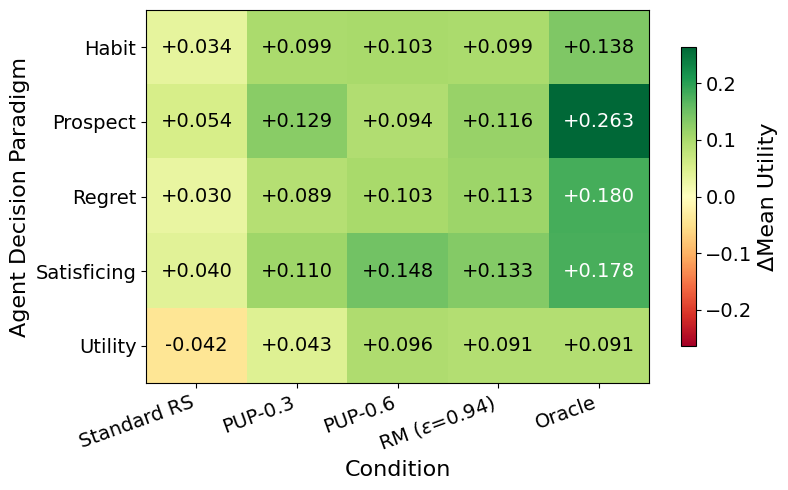

,Standard RS,PUP-0.3,PUP-0.6,RM ($\epsilon$=0.94),Oracle
Habit,0.034112,0.099163,0.102843,0.099346,0.137700
Prospect,0.053982,0.128557,0.094271,0.116355,0.263375
Regret,0.029801,0.088832,0.102565,0.112841,0.179738
Satisficing,0.039987,0.109813,0.147595,0.132552,0.177646
Utility,-0.042131,0.043245,0.095606,0.091086,0.091300


In [48]:
# ── Collect per-paradigm per-agent mean utility ─────────────────────────
paradigm_data = defaultdict(lambda: defaultdict(list))
for treatment in TREATMENTS:
    tname = treatment['name']
    for seed in SEEDS:
        for ad in results[(tname, seed)]['agent_data']:
            paradigm_data[tname][ad['paradigm']].append(ad['mean_utility'])

all_paradigms = sorted({p for tn in paradigm_data for p in paradigm_data[tn]})
heatmap_conditions = [t['name'] for t in TREATMENTS if t['name'] != 'no_rs']
heatmap_labels     = [DISPLAY_NAMES[n] for n in heatmap_conditions]

baseline_by_paradigm = {
    p: (np.mean(paradigm_data['no_rs'][p]) if paradigm_data['no_rs'][p] else 0.0)
    for p in all_paradigms
}

matrix = np.zeros((len(all_paradigms), len(heatmap_conditions)))
for j, tname in enumerate(heatmap_conditions):
    for i, p in enumerate(all_paradigms):
        mean_u = np.mean(paradigm_data[tname][p]) if paradigm_data[tname][p] else 0.0
        matrix[i, j] = mean_u - baseline_by_paradigm[p]

LABEL_SIZE, TICK_SIZE, ANNOT_SIZE = 16, 14, 14
fig, ax = plt.subplots(figsize=(8, 5))
vmax = max(abs(matrix.min()), abs(matrix.max()), 1e-6)
im = ax.imshow(matrix, cmap='RdYlGn', aspect='auto', vmin=-vmax, vmax=vmax)

ax.set_xticks(range(len(heatmap_conditions)))
ax.set_xticklabels(heatmap_labels, fontsize=TICK_SIZE, rotation=20, ha='right')
ax.set_yticks(range(len(all_paradigms)))
ax.set_yticklabels([p.capitalize() for p in all_paradigms], fontsize=TICK_SIZE)

for i in range(len(all_paradigms)):
    for j in range(len(heatmap_conditions)):
        val   = matrix[i, j]
        color = 'white' if abs(val) > vmax * 0.6 else 'black'
        ax.text(j, i, f'{val:+.3f}', ha='center', va='center',
                fontsize=ANNOT_SIZE, color=color)

ax.set_xlabel('Condition', fontsize=LABEL_SIZE)
ax.set_ylabel('Agent Decision Paradigm', fontsize=LABEL_SIZE)
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label(u'\u0394Mean Utility', fontsize=LABEL_SIZE)
cbar.ax.tick_params(labelsize=TICK_SIZE)
plt.tight_layout()
plt.show()

paradigm_table = pd.DataFrame(
    matrix, index=[p.capitalize() for p in all_paradigms], columns=heatmap_labels
)
paradigm_table

## 3. Cost of over-recommendation

In [49]:
# ── Over-recommendation cost (ORC) table ────────────────────────────────
NEUTRAL = 1e-9   # anything strictly above 0 counts as improved, strictly below as harmed

orc_rows = []
for treatment in TREATMENTS:
    tname = treatment['name']
    if tname == 'no_rs':
        continue
    harmed_frac, improved_frac, harmed_orc = [], [], []
    for seed in SEEDS:
        baseline = results[('no_rs', seed)]['agent_utilities']
        treat    = results[(tname,    seed)]['agent_utilities']
        common   = sorted(set(baseline) & set(treat))
        u_b = np.array([baseline[a] for a in common])
        u_t = np.array([treat[a]    for a in common])
        diff = u_t - u_b
        harmed_frac.append(float(np.mean(diff < -NEUTRAL)))
        improved_frac.append(float(np.mean(diff >  NEUTRAL)))
        # Mean loss per harmed agent (not per all agents)
        losses = np.maximum(0.0, u_b - u_t)
        n_harmed = int(np.sum(diff < -NEUTRAL))
        harmed_orc.append(float(np.sum(losses) / n_harmed) if n_harmed else 0.0)
    orc_rows.append({
        'Condition':   DISPLAY_NAMES[tname],
        'Harmed %':    f'{100 * np.mean(harmed_frac):.1f}%',
        'Improved %':  f'{100 * np.mean(improved_frac):.1f}%',
        'Mean ORC':    f'{np.mean(harmed_orc):.3f} ± {np.std(harmed_orc):.3f}',
    })

orc_table = pd.DataFrame(orc_rows)
print('Table 2: Over-recommendation cost (ORC) by condition')
print(orc_table.to_string(index=False))
orc_table

Table 2: Over-recommendation cost (ORC) by condition
           Condition Harmed % Improved %      Mean ORC
         Standard RS    39.7%      43.8% 0.387 ± 0.016
             PUP-0.3    31.4%      50.4% 0.383 ± 0.017
             PUP-0.6    32.2%      51.0% 0.383 ± 0.024
RM ($\epsilon$=0.94)    31.3%      51.8% 0.351 ± 0.026
              Oracle    27.8%      53.4% 0.375 ± 0.013


,Condition,Harmed %,Improved %,Mean ORC
0,Standard RS,39.7%,43.8%,0.387 ± 0.016
1,PUP-0.3,31.4%,50.4%,0.383 ± 0.017
2,PUP-0.6,32.2%,51.0%,0.383 ± 0.024
3,RM ($\epsilon$=0.94),31.3%,51.8%,0.351 ± 0.026
4,Oracle,27.8%,53.4%,0.375 ± 0.013


In [53]:
# Save orc_table to CSV
orc_table.to_csv('figs/orc_table.csv', index=False)